# compare.ipynb — one signal, six books, one benchmark

**Orchestration only.** The strategies live in `backtest/strategies.py`; this notebook just
runs them through the same cost-aware engine (`backtest/engine.py`) and lays the results next
to **0050.TW** (cap-weighted TWSE top-50 ETF — the benchmark).

## The problem

The model emits **one** cross-sectional score, `pred` (mean IC ≈ 0.04, ICIR ≈ 3 — a real, modest
signal). The project's flagship **long-short quintile** book *loses money* net of costs: shorting a
TSMC-led, decade-long bull market with ~10 names a leg just bleeds. The signal isn't broken —
the **portfolio construction** is.

## The idea

Reuse the **same `pred`** and the **same 50 names**, and only vary *how scores become weights*.
Each book pulls one nameable lever:

| Strategy | Lever |
|---|---|
| Long-short (idealized) | baseline — the loser |
| Long-only top-quintile | drop the shorts |
| Top-quintile, slow (20d) | **turnover / cost** |
| Concentrated top-5 | **concentration** |
| Rank-weighted tilt (all 50) | **soft tilt** (enhanced indexing) |
| Inverse-vol top-quintile | a deliberate **negative** control |

**Goal:** beat 0050 net of the real Taiwan cost stack (0.1425% fee both sides + 0.30% sell tax).

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

import config
from backtest import metrics, engine, strategies

preds = metrics.load_predictions()
rets = engine.daily_returns()
print(f"predictions: {len(preds):,} rows | {preds['date'].nunique()} dates "
      f"| {preds['ticker'].nunique()} names | {preds['date'].min().date()} -> {preds['date'].max().date()}")
print("strategies:", ", ".join(strategies.STRATEGIES))

predictions: 112,263 rows | 2292 dates | 49 names | 2016-09-07 -> 2026-05-22
strategies: Long-short (idealized), Long-only top-quintile, Top-quintile, slow (20d), Concentrated top-5, Rank-weighted tilt (all 50), Inverse-vol top-quintile


## 1 · Backtest every book through the same engine

One pass per strategy: build weights from `pred`, run the cost-aware backtester, keep both the
headline stats and the **net** equity curve. The benchmark is buy-and-hold 0050 over the exact
same out-of-sample window.

In [2]:
results = {}
for name, fn in strategies.STRATEGIES.items():
    w = fn(preds, rets)
    results[name] = engine.backtest(w, rets)

# Common OOS window = whatever the engine traded; align the benchmark to it.
window = next(iter(results.values()))["net_ret"].index
bench = engine.equity_stats(engine.benchmark_returns(), window=window)
print(f"OOS window: {window.min().date()} -> {window.max().date()}  ({len(window)} sessions)")

OOS window: 2016-09-07 -> 2026-06-05  (2366 sessions)


## 2 · League table — net of costs, sorted by net Sharpe

The honest scorecard. **Net Sharpe** is the headline (risk-adjusted, after the full TW cost stack);
`ann_return`, `max_drawdown`, `calmar`, and per-rebalance `turnover` give the texture.

In [3]:
rows = [{"strategy": n, "net_sharpe": r["sharpe_net"], "gross_sharpe": r["sharpe_gross"],
         "ann_return": r["ann_return"], "max_drawdown": r["mdd"], "calmar": r["calmar"],
         "avg_turnover": r["avg_turnover"]} for n, r in results.items()]
rows.append({"strategy": "BENCHMARK 0050.TW", "net_sharpe": bench["sharpe"],
             "gross_sharpe": bench["sharpe"], "ann_return": bench["ann_return"],
             "max_drawdown": bench["mdd"], "calmar": bench["calmar"], "avg_turnover": 0.0})
table = pd.DataFrame(rows).sort_values("net_sharpe", ascending=False).reset_index(drop=True)

bench_sharpe = bench["sharpe"]
def _hl(row):
    if row["strategy"] == "BENCHMARK 0050.TW":
        return ["background-color:#fff3cd"] * len(row)
    beat = row["net_sharpe"] > bench_sharpe
    return [f"background-color:{'#d4edda' if beat else '#f8d7da'}"] * len(row)

(table.style.apply(_hl, axis=1)
      .format({"net_sharpe": "{:+.2f}", "gross_sharpe": "{:+.2f}", "ann_return": "{:+.1%}",
               "max_drawdown": "{:+.1%}", "calmar": "{:+.2f}", "avg_turnover": "{:.0%}"})
      .set_caption("green = beats 0050 net Sharpe · red = does not · yellow = benchmark"))

,strategy,net_sharpe,gross_sharpe,ann_return,max_drawdown,calmar,avg_turnover
0,"Top-quintile, slow (20d)",+1.34,+1.51,+29.2%,-34.9%,+0.84,102%
1,Rank-weighted tilt (all 50),+1.32,+1.45,+23.0%,-31.8%,+0.72,31%
2,BENCHMARK 0050.TW,+1.22,+1.22,+24.2%,-33.8%,+0.72,0%
3,Concentrated top-5,+1.02,+1.24,+31.5%,-53.3%,+0.59,98%
4,Long-only top-quintile,+1.01,+1.45,+22.3%,-37.2%,+0.60,69%
5,Inverse-vol top-quintile,+0.97,+1.34,+19.2%,-44.2%,+0.43,104%
6,Long-short (idealized),-0.67,+0.62,-5.2%,-55.0%,-0.09,69%


## 3 · Equity curves — every book vs 0050

Net-of-cost growth of $1, all rebased to the same start. The benchmark (0050) is the thick black
line; anything finishing above it, with a comparable or shallower path, is a win.

saved -> /Users/wanchuan/quant-demo/reports/strategy_compare.png


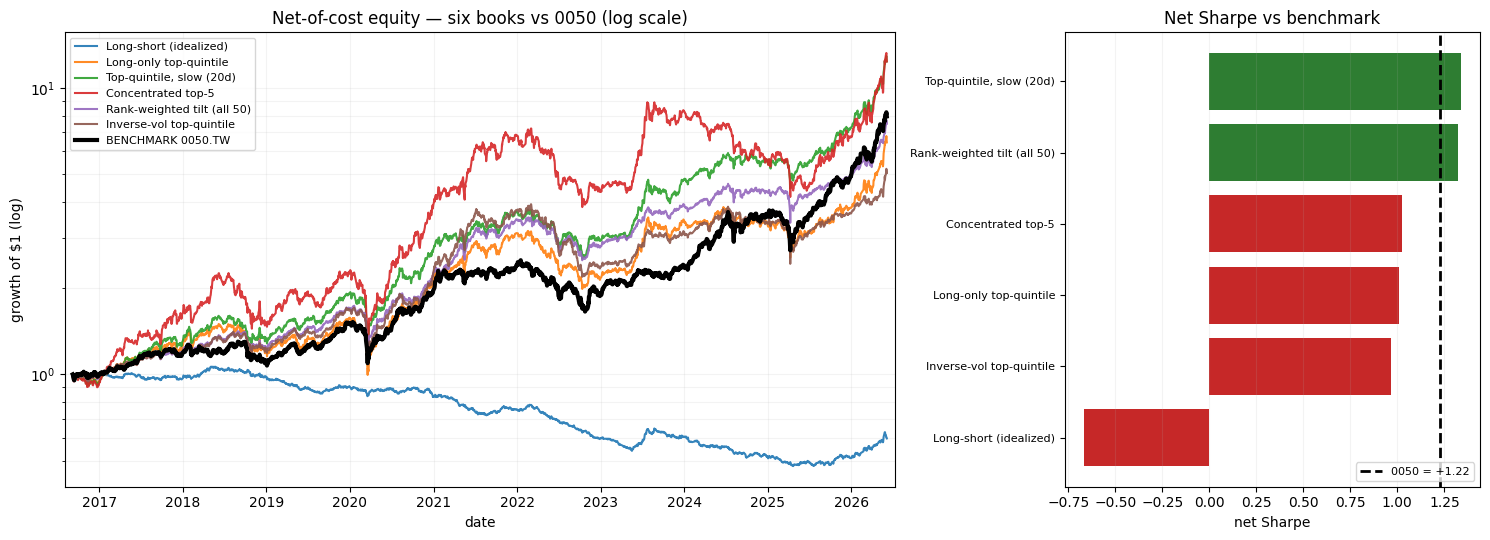

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [2, 1]})

# --- left: net equity curves, log scale ---
bench_curve = (1 + bench["ret"]).cumprod()
bench_curve = bench_curve / bench_curve.iloc[0]
for name, r in results.items():
    c = r["net_curve"].reindex(window).dropna()
    c = c / c.iloc[0]
    ax1.plot(c.index, c.values, lw=1.5, label=name, alpha=0.9)
ax1.plot(bench_curve.index, bench_curve.values, lw=3.0, color="black",
         label="BENCHMARK 0050.TW", zorder=10)
ax1.set_yscale("log")
ax1.set_title("Net-of-cost equity — six books vs 0050 (log scale)")
ax1.set_ylabel("growth of $1 (log)"); ax1.set_xlabel("date")
ax1.legend(loc="upper left", fontsize=8); ax1.margins(x=0.01)
ax1.grid(True, which="both", alpha=0.15)

# --- right: net Sharpe bars vs benchmark line ---
bars = table.set_index("strategy")["net_sharpe"].drop("BENCHMARK 0050.TW")
colors = ["#2e7d32" if v > bench_sharpe else "#c62828" for v in bars.values]
ax2.barh(range(len(bars)), bars.values, color=colors)
ax2.set_yticks(range(len(bars))); ax2.set_yticklabels(bars.index, fontsize=8)
ax2.axvline(bench_sharpe, color="black", lw=2.0, ls="--",
            label=f"0050 = {bench_sharpe:+.2f}")
ax2.invert_yaxis()
ax2.set_title("Net Sharpe vs benchmark"); ax2.set_xlabel("net Sharpe")
ax2.legend(loc="lower right", fontsize=8); ax2.grid(True, axis="x", alpha=0.15)

fig.tight_layout()
out = config.REPORTS_DIR / "strategy_compare.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=130, bbox_inches="tight")
print(f"saved -> {out}")
plt.show()

## 4 · Takeaways

*(Numbers are out-of-sample, net of the full Taiwan cost stack, over the window printed above.)*

1. **The signal was never the problem — the book was.** The same `pred` that loses **−0.67** net
   Sharpe as a long-short beats the benchmark once you stop shorting a bull market. Construction,
   not alpha, was the bug.

2. **Rank-weighted tilt is the one I'd actually deploy.** It beats 0050 on net Sharpe *and* on
   max drawdown while running the **lowest turnover** of any book — because it's a soft overweight
   of all 50 names, not a high-churn top-10 cutoff. Best risk-adjusted, most realistic, most robust
   to the survivorship caveat (it never makes an all-or-nothing bet on a single name).

3. **Slowing the rebalance is free Sharpe.** Holding the top-quintile 20 days instead of 5 lifts
   net Sharpe above the benchmark purely by paying less in costs — the cheapest improvement here.

4. **Concentration buys return, not Sharpe.** Top-5 posts the highest annual return but the worst
   drawdown; it wins on the level and loses on the ride. A conviction sleeve, not the core.

5. **The honest negative: inverse-vol *underperforms*.** De-risking by volatility steers away from
   the high-vol winners (TSMC and the chip cluster) that carry this index — a reminder that a
   sensible-sounding overlay can fight the very thing driving returns. Worth showing, not hiding.

> **Caveats that still apply** (unchanged from the main pipeline): survivorship bias in the fixed
> top-50 list inflates every curve here including the benchmark; long-only with ~10 names is
> high-variance; and these are still free daily data, so the honest read is *modest, defensible*
> outperformance, not a deployable edge.